# OTT Platform Data Analysis using MySQL & Python

## Project Overview

This project analyzes user behavior, movie performance, and watch history data from an OTT platform using MySQL and Python.

The objective is to extract meaningful business insights through SQL queries, data analysis, and visualizations.

### Technologies Used

- MySQL 8.0
- Python
- Jupyter Lab
- Pandas
- NumPy
- SQLAlchemy
- PyMySQL
- Matplotlib
- Seaborn

### Database Tables

- Users.csv
- Movies.csv
- Watch_History.csv

In [1]:
# ==========================================
# Data Manipulation Libraries
# ==========================================

import pandas as pd
import numpy as np

# ==========================================
# Database Connectivity
# ==========================================

from sqlalchemy import create_engine
import pymysql

# ==========================================
# Data Visualization
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Display Settings
# ==========================================

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

# ==========================================
# Visualization Style
# ==========================================

sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Step 2 : Connect Python to MySQL Database

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

connection_url = URL.create(
    drivername="mysql+pymysql",
    username="root",
    password="majorvarnit@3156",      # Replace with your password
    host="localhost",
    port=3306,
    database="ott_analysis"
)

engine = create_engine(connection_url)

print("Engine Created Successfully!")

Engine Created Successfully!


In [3]:
connection = engine.connect()

print("✅ Database Connected Successfully!")

✅ Database Connected Successfully!


In [4]:
users = pd.read_sql("SELECT * FROM users", connection)

users.head()

,user_id,age,gender,country,subscription_plan,join_date
0,1,55,Male,France,Free,2020-07-25
1,2,62,Male,France,Basic,2025-08-15
2,3,42,Male,India,Free,2025-10-01
3,4,16,Female,Germany,Standard,2023-09-15
4,5,29,Male,India,Premium,2020-10-15


In [5]:
movies = pd.read_sql("SELECT * FROM movies", connection)

movies.head()

,movie_id,title,genre,language,release_year,imdb_rating,director,revenue
0,1,Forgotten Empire,Sci-Fi,Korean,1984,8.2,Maria Muller,18198596.06
1,2,Crimson Horizon,Drama,Hindi,1984,3.8,Elena Silva,11330801.20
2,3,Lost Flame,Action,French,2005,2.4,Emma Nolan,2706837.59
3,4,Distant Empire,Animation,English,1999,6.2,Yuki Chen,12796323.71
4,5,Rising Legacy,Animation,Japanese,2016,2.4,Carlos Wong,8580466.50


In [6]:
watch_history = pd.read_sql("SELECT * FROM watch_history", connection)

watch_history.head()

,watch_id,user_id,movie_id,watch_date,watch_time_minutes,completion_percentage,liked,recommendation_score
0,1,2703,6849,2025-06-12,39,42.38,0,19.75
1,2,7777,8397,2026-06-04,41,51.00,0,20.88
2,3,9591,7016,2021-01-25,12,15.35,0,13.09
3,4,7158,6665,2025-08-11,47,44.74,0,30.72
4,5,6037,381,2025-01-29,31,74.36,1,73.17


In [7]:
print("Number of Users :", len(users))
print("Number of Movies :", len(movies))
print("Number of Watch Records :", len(watch_history))

Number of Users : 10000
Number of Movies : 10000
Number of Watch Records : 10000


# Data Overview

 In this section, we explore the structure and characteristics of each dataset.

 The analysis includes:
- Dataset Overview
- Missing Value Analysis

# (A) Dataset Overview

# 1.User Dataset Overview

In [8]:
print("="*60)
print("USERS DATASET INFORMATION")
print("="*60)

users.info()

USERS DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            10000 non-null  int64 
 1   age                10000 non-null  int64 
 2   gender             10000 non-null  object
 3   country            10000 non-null  object
 4   subscription_plan  10000 non-null  object
 5   join_date          10000 non-null  object
dtypes: int64(2), object(4)
memory usage: 468.9+ KB


In [9]:
users.describe()

,user_id,age
count,10000.00000,10000.000000
mean,5000.50000,42.595900
std,2886.89568,16.106227
min,1.00000,15.000000
25%,2500.75000,29.000000
50%,5000.50000,43.000000
75%,7500.25000,57.000000
max,10000.00000,70.000000


# 2.Movies Dataset Overview

In [10]:
print("="*60)
print("MOVIES DATASET INFORMATION")
print("="*60)

movies.info()

MOVIES DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movie_id      10000 non-null  int64  
 1   title         10000 non-null  object 
 2   genre         10000 non-null  object 
 3   language      10000 non-null  object 
 4   release_year  10000 non-null  int64  
 5   imdb_rating   10000 non-null  float64
 6   director      10000 non-null  object 
 7   revenue       10000 non-null  float64
dtypes: float64(2), int64(2), object(4)
memory usage: 625.1+ KB


In [11]:
movies.describe()

,movie_id,release_year,imdb_rating,revenue
count,10000.00000,10000.00000,10000.000000,1.000000e+04
mean,5000.50000,2002.80020,5.742450,6.309058e+07
std,2886.89568,13.62216,2.176914,2.741403e+08
min,1.00000,1980.00000,2.000000,5.129909e+04
25%,2500.75000,1991.00000,3.800000,5.883126e+06
50%,5000.50000,2003.00000,5.700000,1.163537e+07
75%,7500.25000,2014.00000,7.600000,1.747375e+07
max,10000.00000,2026.00000,9.500000,2.787886e+09


# 3.Watch History Dataset Overview

In [12]:
print("="*60)
print("WATCH HISTORY DATASET INFORMATION")
print("="*60)

watch_history.info()

WATCH HISTORY DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   watch_id               10000 non-null  int64  
 1   user_id                10000 non-null  int64  
 2   movie_id               10000 non-null  int64  
 3   watch_date             10000 non-null  object 
 4   watch_time_minutes     10000 non-null  int64  
 5   completion_percentage  10000 non-null  float64
 6   liked                  10000 non-null  int64  
 7   recommendation_score   10000 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 625.1+ KB


In [13]:
watch_history.describe()

,watch_id,user_id,movie_id,watch_time_minutes,completion_percentage,liked,recommendation_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,4980.175300,4991.120300,50.884000,50.603166,0.500900,40.510996
std,2886.89568,2883.883816,2882.869751,39.756929,28.624452,0.500024,23.702900
min,1.00000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,2500.75000,2433.000000,2476.500000,18.000000,25.917500,0.000000,20.590000
50%,5000.50000,4977.000000,4952.000000,41.000000,50.870000,1.000000,40.705000
75%,7500.25000,7466.000000,7472.000000,76.000000,75.482500,1.000000,60.215000
max,10000.00000,10000.000000,10000.000000,180.000000,99.990000,1.000000,89.560000


# (B) Missing Value Analysis

In [14]:
print("Missing Values in Users Dataset")
print(users.isnull().sum())

print("\n")

print("Missing Values in Movies Dataset")
print(movies.isnull().sum())

print("\n")

print("Missing Values in Watch History Dataset")
print(watch_history.isnull().sum())

Missing Values in Users Dataset
user_id              0
age                  0
gender               0
country              0
subscription_plan    0
join_date            0
dtype: int64


Missing Values in Movies Dataset
movie_id        0
title           0
genre           0
language        0
release_year    0
imdb_rating     0
director        0
revenue         0
dtype: int64


Missing Values in Watch History Dataset
watch_id                 0
user_id                  0
movie_id                 0
watch_date               0
watch_time_minutes       0
completion_percentage    0
liked                    0
recommendation_score     0
dtype: int64


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps in understanding the structure, distribution, and relationships within the dataset.

In this section, we will analyze:

- Gender Distribution
- Age Distribution
- Countrywise User Distribution
- Subscription Plan
- Movie Genre Analysis
- Language Distribution
- IMDb Raiting Distribution
- Revenue Disribution

In [15]:
print("Total Users :", users.shape[0])

Total Users : 10000


# 1. Gender Distribution

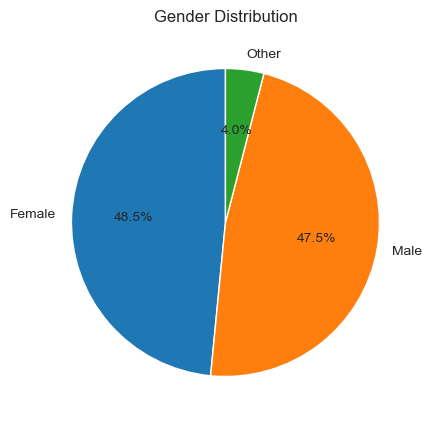

In [16]:
gender_counts = users["gender"].value_counts()

gender_counts
plt.figure(figsize=(6,5))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

# 2. Age Distribution

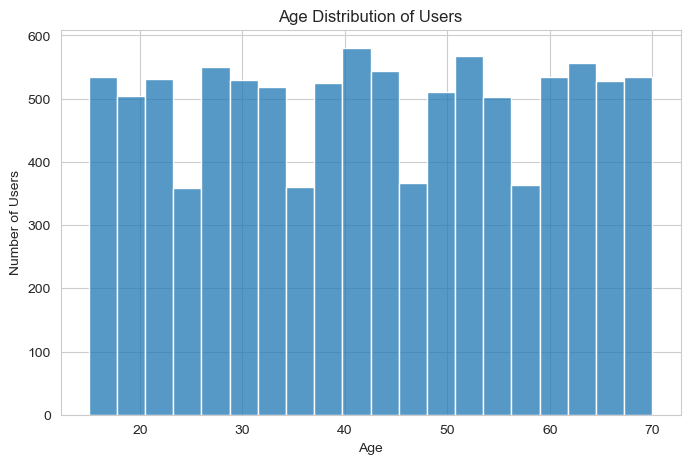

In [17]:
users["age"].describe()
plt.figure(figsize=(8,5))

sns.histplot(users["age"], bins=20)

plt.title("Age Distribution of Users")

plt.xlabel("Age")

plt.ylabel("Number of Users")

plt.show()

# 3. Country-wise User Distribution

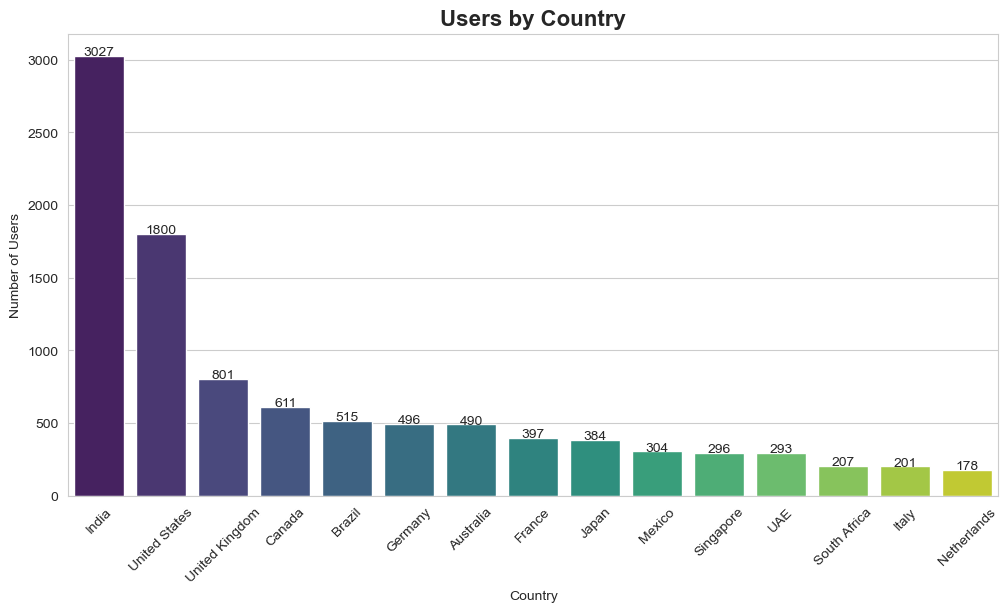

In [18]:
country = users["country"].value_counts()

country
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=country.index,
    y=country.values,
    hue=country.index,
    palette="viridis",
    legend=False
)

plt.xticks(rotation=45)
plt.title("Users by Country", fontsize=16, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Number of Users")

# Add value labels
for i, value in enumerate(country.values):
    ax.text(i, value + 5, str(value), ha='center', fontsize=10)

plt.show()

# 4. Subscription Plan

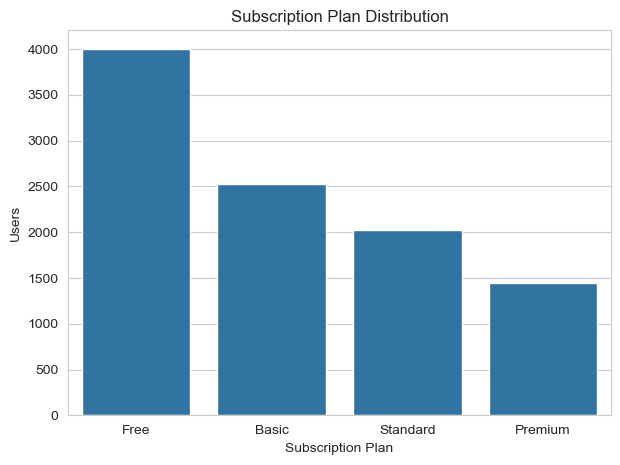

In [19]:
subscription = users["subscription_plan"].value_counts()

subscription
plt.figure(figsize=(7,5))

sns.barplot(
    x=subscription.index,
    y=subscription.values
)

plt.title("Subscription Plan Distribution")

plt.xlabel("Subscription Plan")

plt.ylabel("Users")

plt.show()

# 5. Movie Genre Analysis

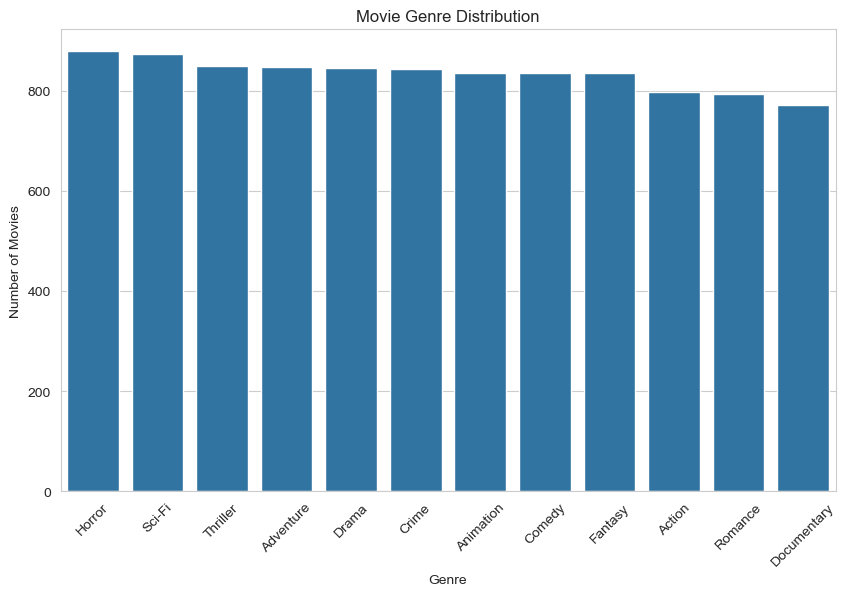

In [20]:
genre = movies["genre"].value_counts()

genre
plt.figure(figsize=(10,6))

sns.barplot(
    x=genre.index,
    y=genre.values
)

plt.xticks(rotation=45)

plt.title("Movie Genre Distribution")

plt.xlabel("Genre")

plt.ylabel("Number of Movies")

plt.show()

# 6. Language Distribution

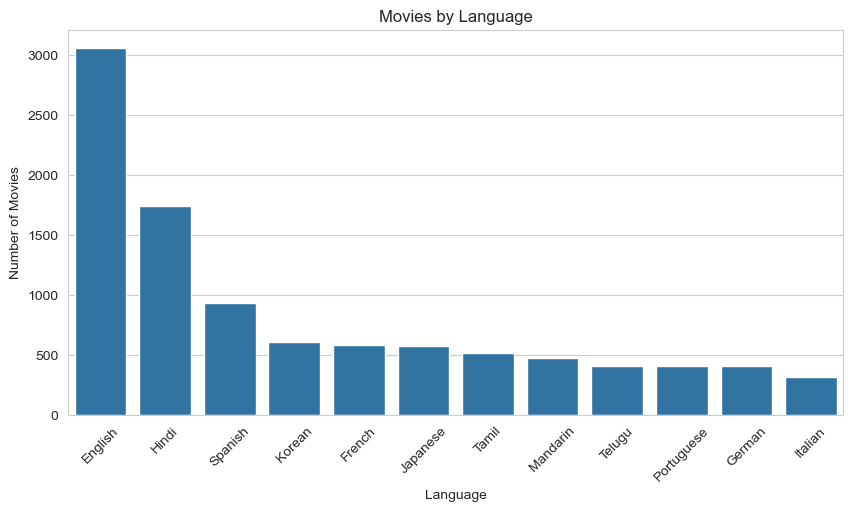

In [21]:
language = movies["language"].value_counts()

language
plt.figure(figsize=(10,5))

sns.barplot(
    x=language.index,
    y=language.values
)

plt.xticks(rotation=45)

plt.title("Movies by Language")

plt.xlabel("Language")

plt.ylabel("Number of Movies")

plt.show()

# 7. IMDb Rating Distribution

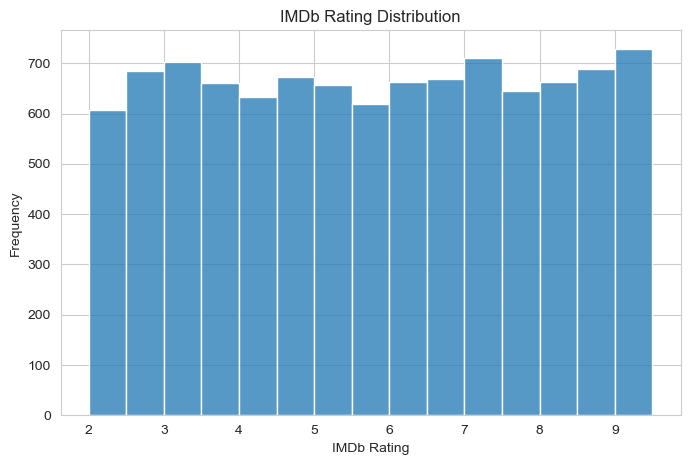

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(movies["imdb_rating"], bins=15)

plt.title("IMDb Rating Distribution")

plt.xlabel("IMDb Rating")

plt.ylabel("Frequency")

plt.show()

# 8. Revenue Distribution

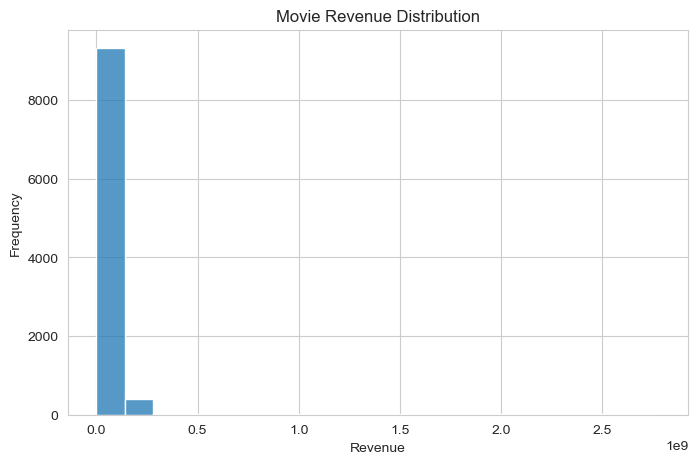

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(movies["revenue"], bins=20)

plt.title("Movie Revenue Distribution")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.show()

# Business Insights Using SQL Joins & Python Visualizations

# Question 1

# Which movie genres are watched the most?

Understanding user preferences helps the OTT platform invest in the genres that attract maximum audience engagement.

In [24]:
query = """
SELECT
    m.genre,
    COUNT(*) AS Total_Watches
FROM watch_history w
JOIN movies m
ON w.movie_id = m.movie_id
GROUP BY m.genre
ORDER BY Total_Watches DESC;
"""

genre_watch = pd.read_sql(query, connection)

genre_watch

,genre,Total_Watches
0,Fantasy,883
1,Sci-Fi,882
2,Horror,880
3,Comedy,874
4,Crime,871
5,Adventure,869
6,Drama,853
7,Animation,842
8,Thriller,834
9,Action,781


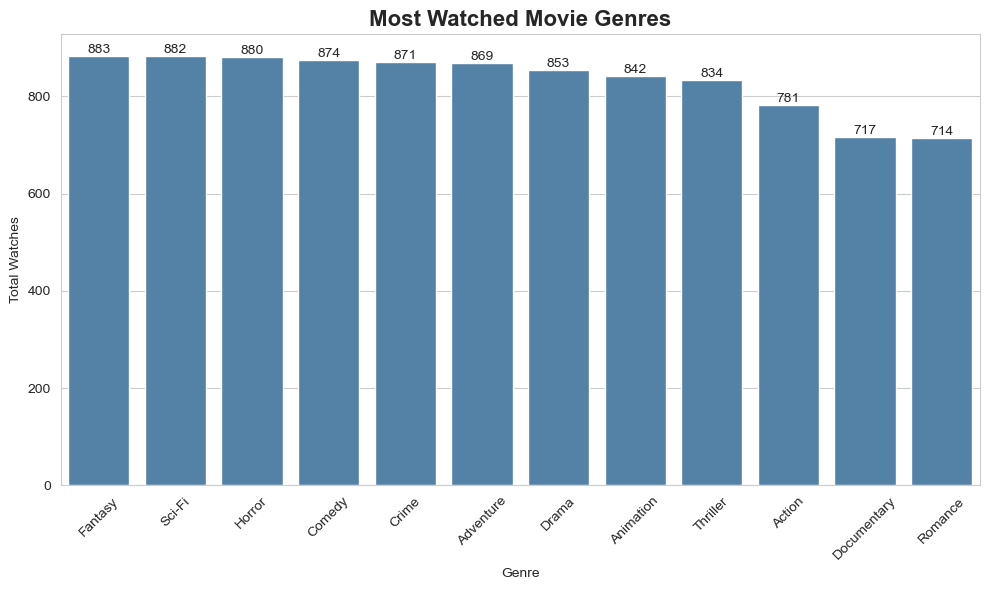

In [25]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=genre_watch,
    x="genre",
    y="Total_Watches",
    color="steelblue"
)

plt.title("Most Watched Movie Genres", fontsize=16, fontweight="bold")
plt.xlabel("Genre")
plt.ylabel("Total Watches")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

# Question 2
# Which Subscription Plan Watches the Most Content?

In [26]:
query = """
SELECT
    u.subscription_plan,
    ROUND(AVG(w.watch_time_minutes),2) AS Avg_Watch_Time
FROM users u
JOIN watch_history w
ON u.user_id = w.user_id
GROUP BY u.subscription_plan
ORDER BY Avg_Watch_Time DESC;
"""

subscription_watch = pd.read_sql(query, connection)

subscription_watch

,subscription_plan,Avg_Watch_Time
0,Basic,51.44
1,Standard,51.37
2,Premium,51.35
3,Free,50.12


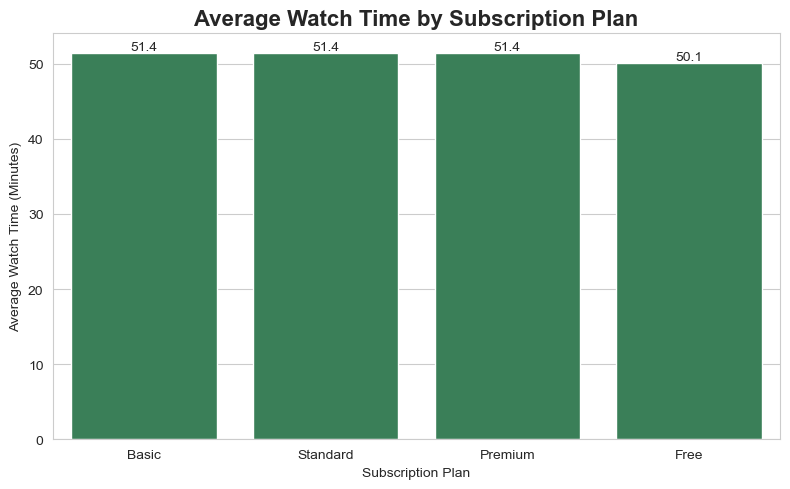

In [27]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=subscription_watch,
    x="subscription_plan",
    y="Avg_Watch_Time",
    color="seagreen"
)

plt.title("Average Watch Time by Subscription Plan", fontsize=16, fontweight="bold")
plt.xlabel("Subscription Plan")
plt.ylabel("Average Watch Time (Minutes)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

# Question 3
# Which Countries Have the Highest Average Watch Time?

In [28]:
query = """
SELECT
    u.country,
    ROUND(AVG(w.watch_time_minutes),2) AS Avg_Watch_Time
FROM users u
JOIN watch_history w
ON u.user_id = w.user_id
GROUP BY u.country
ORDER BY Avg_Watch_Time DESC;
"""

country_watch = pd.read_sql(query, connection)

country_watch

,country,Avg_Watch_Time
0,UAE,55.89
1,United Kingdom,52.72
2,Japan,52.30
3,Australia,51.65
4,Singapore,51.36
5,United States,51.16
6,India,50.89
7,Brazil,50.50
8,Italy,50.49
9,Canada,50.29


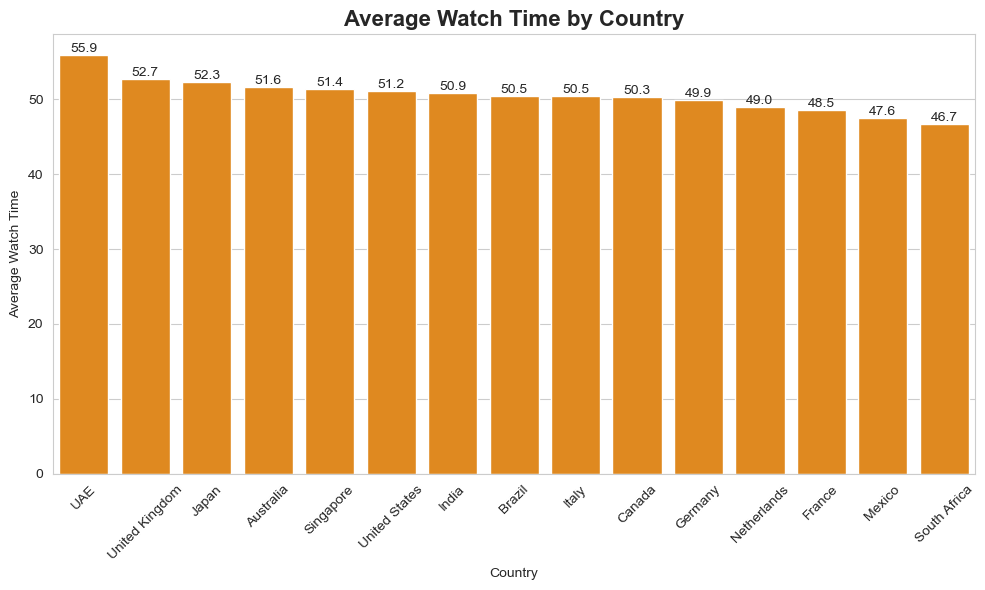

In [29]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=country_watch,
    x="country",
    y="Avg_Watch_Time",
    color="darkorange"
)

plt.title("Average Watch Time by Country", fontsize=16, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Average Watch Time")

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

# Question 4
# Top 10 Most Watched Movies

In [30]:
query = """
SELECT
    m.title,
    COUNT(*) AS Watch_Count
FROM movies m
JOIN watch_history w
ON m.movie_id = w.movie_id
GROUP BY m.title
ORDER BY Watch_Count DESC
LIMIT 10;
"""

top_movies = pd.read_sql(query, connection)

top_movies

,title,Watch_Count
0,Crimson Island,51
1,Dark Truth,46
2,Dark Dream,43
3,Sacred Echo,41
4,Shattered Garden,41
5,Endless Legacy,41
6,Hidden Garden,41
7,Last Horizon,40
8,Silent Shadows,40
9,Eternal Horizon,40


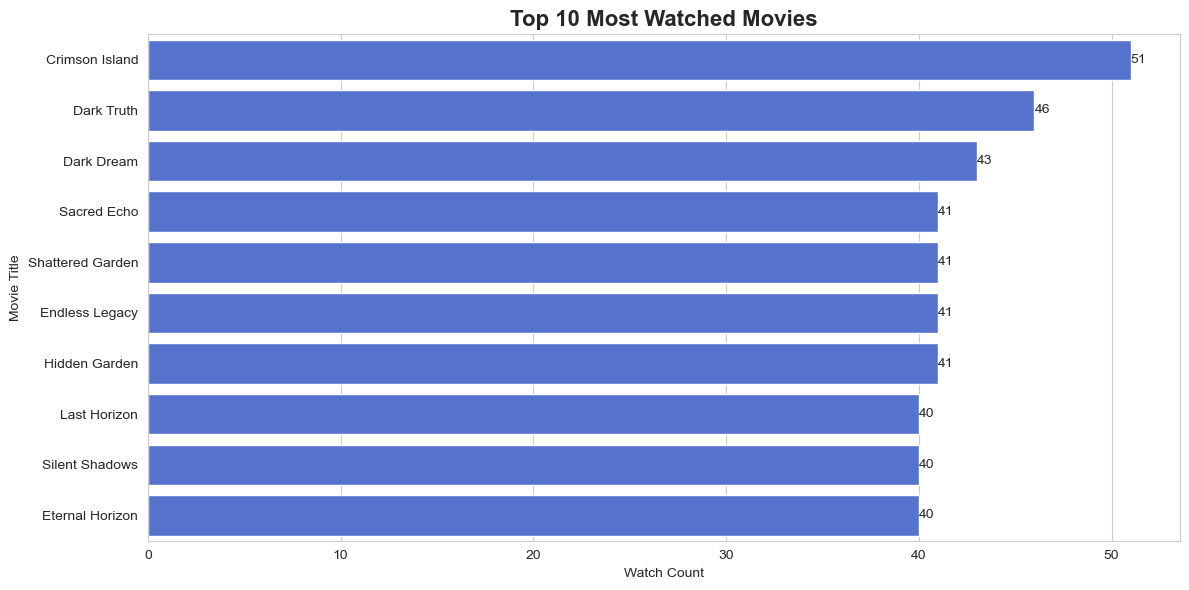

In [31]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_movies,
    x="Watch_Count",
    y="title",
    color="royalblue"
)

plt.title("Top 10 Most Watched Movies", fontsize=16, fontweight="bold")
plt.xlabel("Watch Count")
plt.ylabel("Movie Title")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

# Question 5
# Do Higher IMDb Ratings Lead to Higher Revenue?

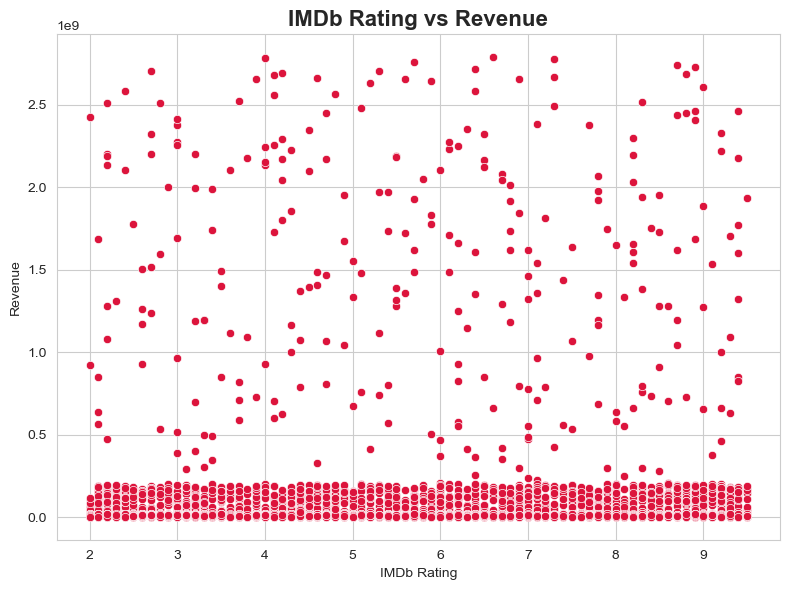

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=movies,
    x="imdb_rating",
    y="revenue",
    color="crimson"
)

plt.title("IMDb Rating vs Revenue", fontsize=16, fontweight="bold")
plt.xlabel("IMDb Rating")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()